In [1]:
import redis
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("All libraries imported successfully!")
print("PyArrow version:", pa.__version__)
print("Redis version:", redis.__version__)

All libraries imported successfully!
PyArrow version: 23.0.1
Redis version: 6.4.0


In [2]:
import pandas as pd
from sqlalchemy import create_engine


In [5]:
# from urllib.parse import quote_plus
# from sqlalchemy import create_engine

# username = "mariadbuser"
# password = quote_plus("Samikshya@123")
# host = "localhost"
# port = 3306
# database = "raw_ai_jobs"

# engine = create_engine(
#     f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
# )

In [9]:
import pandas as pd
print(pd.read_csv("/home/samiksya/ai_job_market/data/raw/ai_jobs.csv").columns.tolist())

['job_id', 'job_title', 'salary_usd', 'salary_currency', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'required_skills', 'education_required', 'years_experience', 'industry', 'posting_date', 'application_deadline', 'job_description_length', 'benefits_score', 'company_name']


In [10]:
df = pd.read_csv("/home/samiksya/ai_job_market/data/raw/ai_jobs.csv")
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [11]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [12]:
df.duplicated().sum()

np.int64(0)

<Axes: >

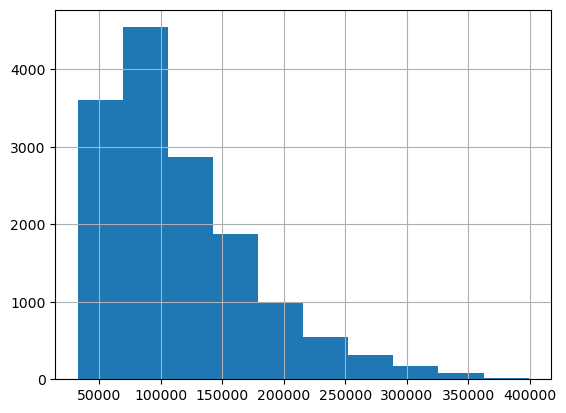

In [13]:
df['salary_usd'].hist()

<Axes: >

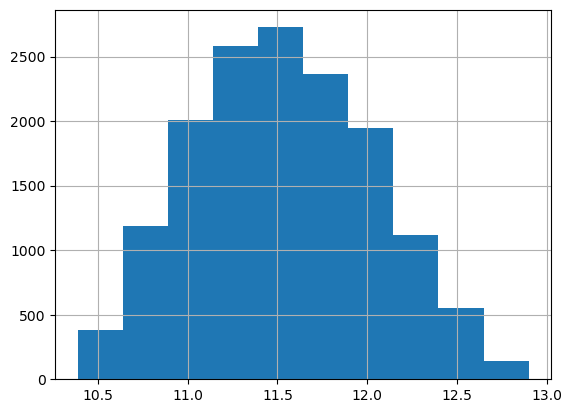

In [14]:
import numpy as np
df['log_salary'] = np.log1p(df['salary_usd'])
df['log_salary'].hist()

In [20]:
# import plotly.io as pio
# pio.renderers.default ='notebook_connected'
# import plotly.express as px
# import plotly.graph_objects as go
# import plotly.io as pio

In [23]:
!!pip install seaborn

['\x1bWARNING: Cache entry deserialization failed, entry ignored\x1b\x1b',
 '\x1bCollecting seaborn',
 '  Downloading seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)',
 'Requirement already satisfied: numpy!=1.24.0,>=1.20 in ./miniconda3/envs/pipeline_ingestion/lib/python3.10/site-packages (from seaborn) (2.2.6)',
 'Requirement already satisfied: pandas>=1.2 in ./miniconda3/envs/pipeline_ingestion/lib/python3.10/site-packages (from seaborn) (1.5.3)',
 'Requirement already satisfied: matplotlib!=3.6.1,>=3.4 in ./miniconda3/envs/pipeline_ingestion/lib/python3.10/site-packages (from seaborn) (3.10.8)',
 'Requirement already satisfied: contourpy>=1.0.1 in ./miniconda3/envs/pipeline_ingestion/lib/python3.10/site-packages (from matplotlib!=3.6.1,>=3.4->seaborn) (1.3.2)',
 'Requirement already satisfied: cycler>=0.10 in ./miniconda3/envs/pipeline_ingestion/lib/python3.10/site-packages (from matplotlib!=3.6.1,>=3.4->seaborn) (0.12.1)',
 'Requirement already satisfied: fonttools>=4.22.0 in ./

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns


    job_id              job_title  salary_usd salary_currency  \
0  AI00001  AI Research Scientist       90376             USD   
1  AI00002   AI Software Engineer       61895             USD   
2  AI00003          AI Specialist      152626             USD   
3  AI00004           NLP Engineer       80215             USD   
4  AI00005          AI Consultant       54624             EUR   

  experience_level employment_type company_location company_size  \
0               SE              CT            China            M   
1               EN              CT           Canada            M   
2               MI              FL      Switzerland            L   
3               SE              FL            India            M   
4               EN              PT           France            S   

  employee_residence  remote_ratio  \
0              China            50   
1            Ireland           100   
2        South Korea             0   
3              India            50   
4         

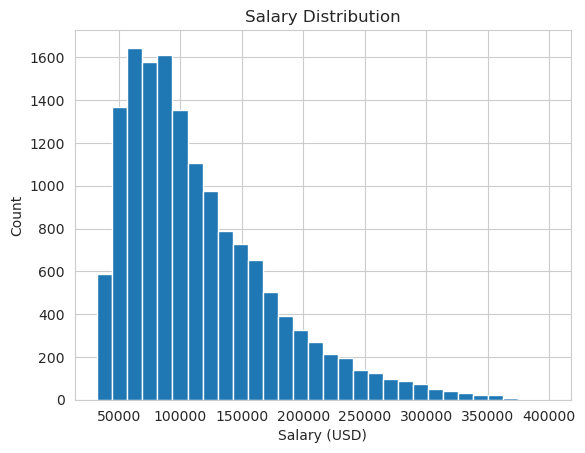

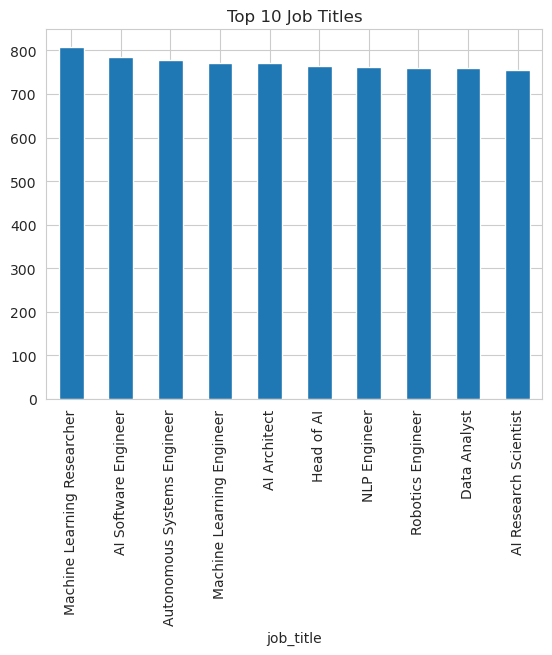

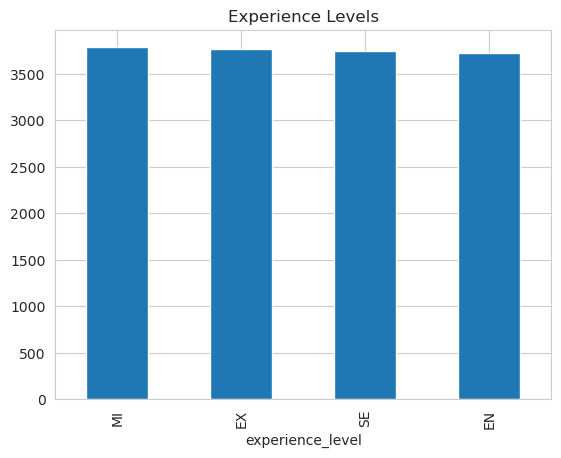

company_location
Germany      814
Denmark      778
Canada       769
France       769
Austria      765
Singapore    764
China        763
India        754
Sweden       752
Israel       751
Name: count, dtype: int64
                        salary_usd  remote_ratio  years_experience  \
salary_usd                1.000000      0.013727          0.737556   
remote_ratio              0.013727      1.000000          0.015321   
years_experience          0.737556      0.015321          1.000000   
job_description_length   -0.009092      0.004475         -0.007526   
benefits_score            0.000985      0.003139         -0.007275   
log_salary                0.957772      0.017191          0.755873   

                        job_description_length  benefits_score  log_salary  
salary_usd                           -0.009092        0.000985    0.957772  
remote_ratio                          0.004475        0.003139    0.017191  
years_experience                     -0.007526       -0.007275   

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# # Load data
# df = pd.read_csv("ai_job_dataset.csv")

# Basic overview
print(df.head())
print(df.shape)
print(df.info())

# Missing values
print(df.isnull().sum())

# Duplicate rows
print("Duplicates:", df.duplicated().sum())

# Numerical summary
print(df.describe())

# Salary distribution
df['salary_usd'].hist(bins=30)
plt.title("Salary Distribution")
plt.xlabel("Salary (USD)")
plt.ylabel("Count")
plt.show()

# Top job titles
df['job_title'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Job Titles")
plt.show()

# Experience level counts
df['experience_level'].value_counts().plot(kind='bar')
plt.title("Experience Levels")
plt.show()

# Company locations
print(df['company_location'].value_counts().head(10))

# Correlation (numerical columns only)
print(df.select_dtypes(include='number').corr())

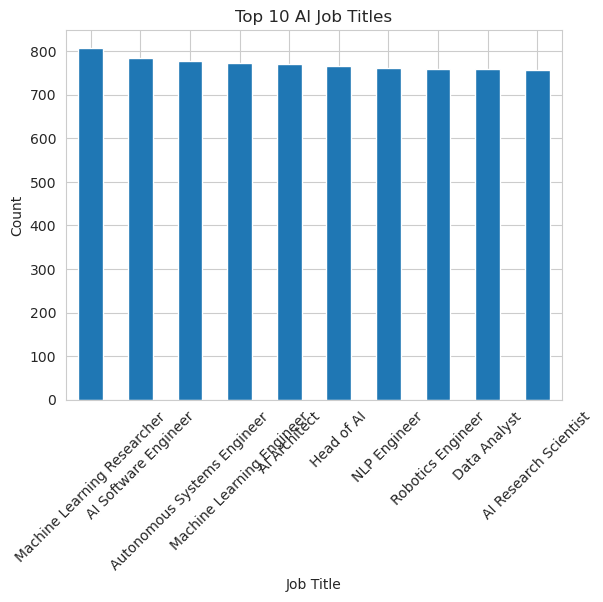

In [35]:
df['job_title'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 AI Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [37]:
df['job_title'].value_counts()

job_title
Machine Learning Researcher    808
AI Software Engineer           784
Autonomous Systems Engineer    777
Machine Learning Engineer      772
AI Architect                   771
Head of AI                     765
NLP Engineer                   762
Robotics Engineer              759
Data Analyst                   759
AI Research Scientist          756
Data Engineer                  749
AI Product Manager             743
Research Scientist             742
Principal Data Scientist       734
AI Specialist                  728
ML Ops Engineer                725
Computer Vision Engineer       724
Data Scientist                 720
Deep Learning Engineer         718
AI Consultant                  704
Name: count, dtype: int64

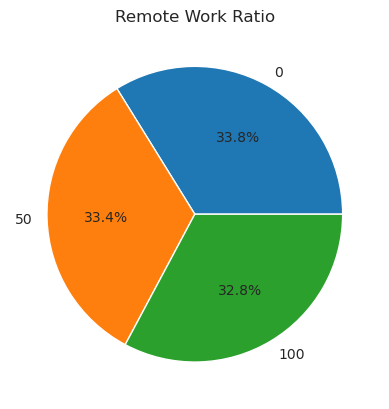

In [30]:
df['remote_ratio'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Remote Work Ratio')
plt.ylabel('')
plt.show()

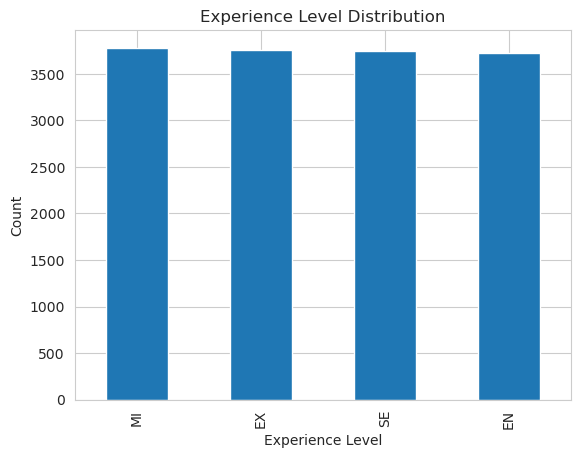

In [32]:
df['experience_level'].value_counts().plot(kind='bar')
plt.title('Experience Level Distribution')
plt.xlabel('Experience Level')
plt.ylabel('Count')
plt.show()

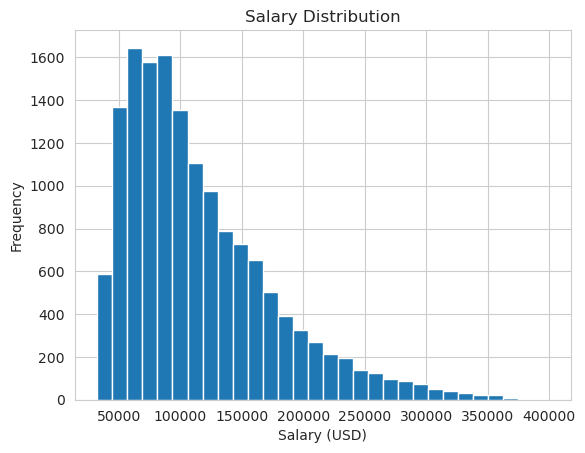

In [33]:
import matplotlib.pyplot as plt

plt.hist(df['salary_usd'], bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')
plt.show()